## Group Comparisons in PFMs

In [1]:
import os
import os.path as op
import pandas as pd
import numpy as np
import nibabel as nib
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

datapool_root_folder = '/mnt_AdaBD_largefiles/Data/DNumRisk_Data'#. #'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk'
dataset = 'smile' #'numberline'  #
bids_folder = op.join(datapool_root_folder, f'ds-{dataset}')

subList = [int(d[4:]) for d in os.listdir(bids_folder) if d.startswith('sub-')]
group_mapping = pd.DataFrame({'group':[int(d[4]) for d in os.listdir(bids_folder) if d.startswith('sub-')]},index=subList)
group_mapping['group'] = group_mapping['group'].map({1:'DD',2:'DD',3:'control'}) # works for both datasets

from utils import get_NPC_mask, get_basic_mask
nprf_r2 = get_NPC_mask()
mask, _ = get_basic_mask()

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [2]:
sessions = '1-2'
tasks = 'magjudge-placevalue-rest'
conn_thresholds = [0.03, 0.04, 0.05, 0.1, 0.2, 0.4] 
conn_thresholds_string = "-".join([str(t) for t in conn_thresholds])


In [ ]:
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap')

from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

df_nets_counts = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=subList, dtype=float)
df_nets_counts.index.name = 'subject'
df_nets_counts = df_nets_counts.join(group_mapping).set_index(['group'], append=True)

only_NPC = True
npc_mask = nprf_r2
hemi = 'both'
cleaned = False

for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}', f'sub-{sub}_ses-{sessions}_task-{tasks}_threshs-{conn_thresholds_string}_precFuncMaps-consensMap.npy'))
        if only_NPC:
            nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
            nets_fsav5[mask] = nets
            nets = nets_fsav5[npc_mask]
        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets_counts.loc[sub, f'net_{int(net)}'] = count

    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')

df_nets = df_nets_counts #

Text(0.5, 1.02, 'Group comparison: Network sizes \n NPC mask - True, hemi-both, cleaned - False')

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


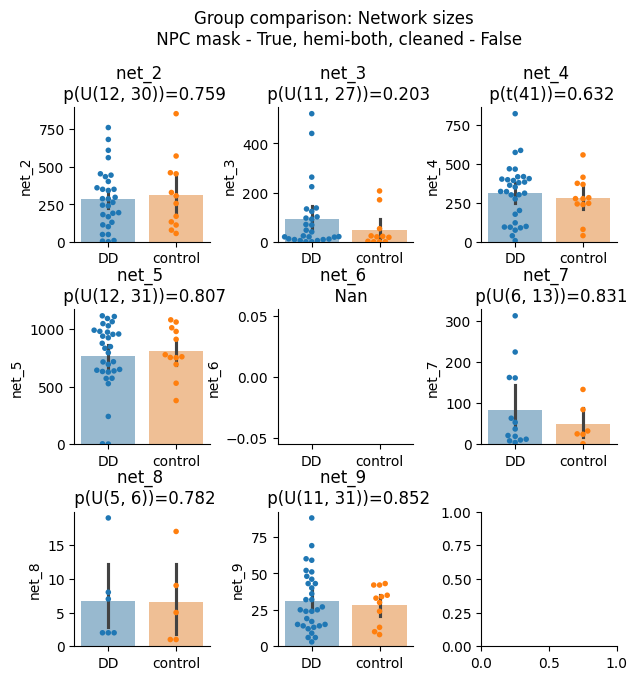

In [5]:
# between group test:
from utils import between_group_comparison
import seaborn as sns

figure, axes = plt.subplots(3, 3, figsize=(7,7))
axs = axes.flatten()
for i, net in enumerate(df_nets.columns[:8]):
    sns.barplot(data=df_nets.reset_index(), x='group', hue='group', y=net, alpha=0.5, legend=False, ax=axs[i])
    sns.swarmplot(data=df_nets.reset_index(), x='group', hue='group', y=net, size=4, legend=False, ax=axs[i])
    try:
        stats, stats_term = between_group_comparison(df_nets, net, group_names=['control','DD'])
        axs[i].set(xlabel=None, title=f'{net} \n p({stats_term})={stats.pvalue:.3f}')
    except Exception as e:
        axs[i].set(xlabel=None, title=f'{net} \n  Nan')

plt.subplots_adjust(hspace=0.5,wspace=0.5)
sns.despine()
figure.suptitle(f'Group comparison: Network sizes \n NPC mask - {only_NPC}, hemi-{hemi}, cleaned - {cleaned}', y=1.02)